# ⚙️ Notebook 3: Hyperparameter Tuning with LightGBM — Nested CV

**Project:** Bitcoin (BTC-USD) Direction Prediction with Gradient Boosting  
**Description:** We migrate to LightGBM and tune hyperparameters using **Nested Cross-Validation**, the methodologically correct approach that prevents the optimism bias caused by tuning and evaluating on the same data.

---

> **Fix applied (critical):** The original notebooks used `RandomizedSearchCV` with `TimeSeriesSplit` for tuning, then re-evaluated the best model using the same data. This gives an over-optimistic AUC because the hyperparameters were selected to maximise performance on those exact splits.  
>  
> **Nested CV** separates concerns into two loops:  
> - **Inner loop:** selects the best hyperparameters using walk-forward CV on the training folds  
> - **Outer loop:** evaluates the tuned model on a completely held-out test fold  
>  
> The reported AUC from the outer loop is an honest, unbiased estimate of generalisation performance.

---

## 📋 Contents
1. Why Nested CV?  
2. LightGBM baseline  
3. Nested Cross-Validation (inner tuning + outer evaluation)  
4. Hyperparameter search space analysis  
5. Learning curves with early stopping  
6. Final optimised model


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from scipy.stats import uniform, randint

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

DATA_DIR   = Path('data')
MODELS_DIR = Path('models')

print(f'✅ LightGBM version: {lgb.__version__}')


✅ LightGBM version: 4.6.0


## 1. ⚡ Why LightGBM? And Why Nested CV?

### LightGBM advantages over sklearn GBM

| Feature | sklearn GBM | LightGBM |
|---------|-------------|----------|
| Training speed | Slow | 10–100× faster |
| Memory usage | High | Much lower |
| Categorical features | Manual encoding | Native support |
| Early stopping | No | ✅ Built-in |

### The Nested CV problem

Standard approach (flawed):
```
RandomizedSearchCV(cv=TimeSeriesSplit(5)).fit(X, y)   # selects best params
→  evaluate best model on same X, y                   # BIASED — params chosen to do well here
```

Nested CV (correct):
```
Outer loop fold k → held-out test set (never seen during tuning)
   Inner loop → RandomizedSearchCV finds best params on training folds only
   → evaluate on outer test set → honest AUC
Repeat for all outer folds → mean outer AUC = unbiased performance estimate
```


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'btc_features.csv', index_col=0, parse_dates=True)

FEATURE_COLS = [c for c in df.columns if c not in ['Close', 'target']]
X = df[FEATURE_COLS].values
y = df['target'].values
feature_names = FEATURE_COLS

print(f'📐 X shape: {X.shape}  |  y shape: {y.shape}')


📐 X shape: (105, 14)  |  y shape: (105,)


## 2. 🚀 LightGBM Baseline (Walk-Forward CV)

In [3]:
def lgbm_walk_forward(params, X, y, n_splits=5):
    """
    Evaluate LightGBM using Walk-Forward CV.
    Early stopping is applied within each fold.
    Returns mean and std AUC across folds.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    aucs = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Temporal validation split within the training fold for early stopping
        val_size  = max(1, int(len(X_train) * 0.15))
        X_tr_es   = X_train[:-val_size]
        y_tr_es   = y_train[:-val_size]
        X_val_es  = X_train[-val_size:]
        y_val_es  = y_train[-val_size:]

        model = lgb.LGBMClassifier(**params, verbose=-1)
        model.fit(
            X_tr_es, y_tr_es,
            eval_set=[(X_val_es, y_val_es)],
            callbacks=[
                lgb.early_stopping(20, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )
        y_prob = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_prob))

    return np.mean(aucs), np.std(aucs)


baseline_params = {
    'n_estimators':     300,
    'learning_rate':    0.05,
    'max_depth':        4,
    'num_leaves':       15,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'random_state':     42,
    'n_jobs':          -1,
}

print('⏱️  Evaluating LightGBM baseline...')
t0 = time.time()
auc_baseline, std_baseline = lgbm_walk_forward(baseline_params, X, y)
elapsed = time.time() - t0

print(f'\n✅ LightGBM Baseline:')
print(f'   AUC  = {auc_baseline:.4f} ± {std_baseline:.4f}')
print(f'   Time = {elapsed:.1f}s')


⏱️  Evaluating LightGBM baseline...

✅ LightGBM Baseline:
   AUC  = 0.4826 ± 0.0308
   Time = 0.0s


## 3. 🎯 Nested Cross-Validation

Two nested loops:
- **Outer loop (5 folds):** provides unbiased OOS evaluation
- **Inner loop (3 folds):** finds best hyperparameters — never touches outer test fold


In [4]:
def nested_cv(X, y, param_dist, n_outer=5, n_inner=3, n_iter=30, random_state=42):
    """
    Nested Walk-Forward Cross-Validation for honest hyperparameter tuning.

    Outer loop: TimeSeriesSplit(n_outer) — each outer test fold is NEVER
                seen during inner-loop tuning.
    Inner loop: RandomizedSearchCV with TimeSeriesSplit(n_inner) — selects
                best hyperparameters purely from outer training data.

    Returns
    -------
    outer_aucs     : list of per-fold AUCs (unbiased generalisation estimate)
    best_params_per_fold : list of best param dicts chosen per outer fold
    all_y_true, all_y_prob : concatenated labels and probabilities (for ROC)
    """
    outer_tscv = TimeSeriesSplit(n_splits=n_outer)
    inner_tscv = TimeSeriesSplit(n_splits=n_inner)

    outer_aucs          = []
    best_params_per_fold = []
    all_y_true, all_y_prob = [], []

    print(f'🔄 Nested CV: {n_outer} outer folds × {n_inner} inner folds × {n_iter} candidates')
    print('=' * 68)

    for fold, (outer_train_idx, outer_test_idx) in enumerate(outer_tscv.split(X), 1):
        X_outer_train = X[outer_train_idx]
        y_outer_train = y[outer_train_idx]
        X_outer_test  = X[outer_test_idx]
        y_outer_test  = y[outer_test_idx]

        # ── Inner loop: hyperparameter search on outer_train only ────────────
        lgbm_base = lgb.LGBMClassifier(random_state=random_state, verbose=-1, n_jobs=-1)

        inner_search = RandomizedSearchCV(
            estimator           = lgbm_base,
            param_distributions = param_dist,
            n_iter              = n_iter,
            cv                  = inner_tscv,
            scoring             = 'roc_auc',
            n_jobs              = -1,
            random_state        = random_state + fold,
            verbose             = 0
        )
        inner_search.fit(X_outer_train, y_outer_train)

        best_params = inner_search.best_params_
        best_params_per_fold.append(best_params)

        # ── Outer evaluation: best model from inner → outer test fold ────────
        final_model = lgb.LGBMClassifier(
            **best_params, random_state=random_state, verbose=-1, n_jobs=-1
        )
        final_model.fit(X_outer_train, y_outer_train)
        y_prob = final_model.predict_proba(X_outer_test)[:, 1]
        auc    = roc_auc_score(y_outer_test, y_prob)

        outer_aucs.append(auc)
        all_y_true.extend(y_outer_test.tolist())
        all_y_prob.extend(y_prob.tolist())

        print(f'  Fold {fold}: inner best CV AUC={inner_search.best_score_:.3f} | '
              f'outer test AUC={auc:.3f} | '
              f'test n={len(outer_test_idx)} '
              f'[{df.index[outer_test_idx[0]].date()} → {df.index[outer_test_idx[-1]].date()}]')

    overall_auc = roc_auc_score(all_y_true, all_y_prob)

    print(f'\n✅ Nested CV complete')
    print(f'   Outer mean AUC  : {np.mean(outer_aucs):.4f} ± {np.std(outer_aucs):.4f}')
    print(f'   Overall OOS AUC : {overall_auc:.4f}  (all outer predictions concatenated)')
    print(f'\n⚠️  Note: inner CV AUC > outer AUC is expected — this gap measures')
    print(f'   optimism from hyperparameter selection. Nested CV corrects for it.')

    return outer_aucs, best_params_per_fold, all_y_true, all_y_prob


# ── Hyperparameter search space ────────────────────────────────────────────
param_dist = {
    'n_estimators':      randint(100, 500),
    'learning_rate':     uniform(0.01, 0.19),
    'max_depth':         randint(2, 7),
    'num_leaves':        randint(8, 63),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_samples': randint(5, 30),
    'reg_alpha':         uniform(0, 0.5),
    'reg_lambda':        uniform(0, 1.0),
}

# Run nested CV
t0 = time.time()
outer_aucs, best_params_list, nested_y_true, nested_y_prob = nested_cv(
    X, y, param_dist, n_outer=5, n_inner=3, n_iter=30
)
elapsed = time.time() - t0
print(f'\n⏱️  Total time: {elapsed/60:.1f} minutes')


🔄 Nested CV: 5 outer folds × 3 inner folds × 30 candidates
  Fold 1: inner best CV AUC=nan | outer test AUC=0.500 | test n=17 [2017-11-30 → 2019-03-31]
  Fold 2: inner best CV AUC=0.607 | outer test AUC=0.486 | test n=17 [2019-04-30 → 2020-08-31]
  Fold 3: inner best CV AUC=0.500 | outer test AUC=0.571 | test n=17 [2020-09-30 → 2022-01-31]
  Fold 4: inner best CV AUC=0.519 | outer test AUC=0.417 | test n=17 [2022-02-28 → 2023-06-30]
  Fold 5: inner best CV AUC=0.543 | outer test AUC=0.517 | test n=17 [2023-07-31 → 2024-11-30]

✅ Nested CV complete
   Outer mean AUC  : 0.4982 ± 0.0500
   Overall OOS AUC : 0.4606  (all outer predictions concatenated)

⚠️  Note: inner CV AUC > outer AUC is expected — this gap measures
   optimism from hyperparameter selection. Nested CV corrects for it.

⏱️  Total time: 0.2 minutes


## 4. 📊 Hyperparameter Search Space Analysis

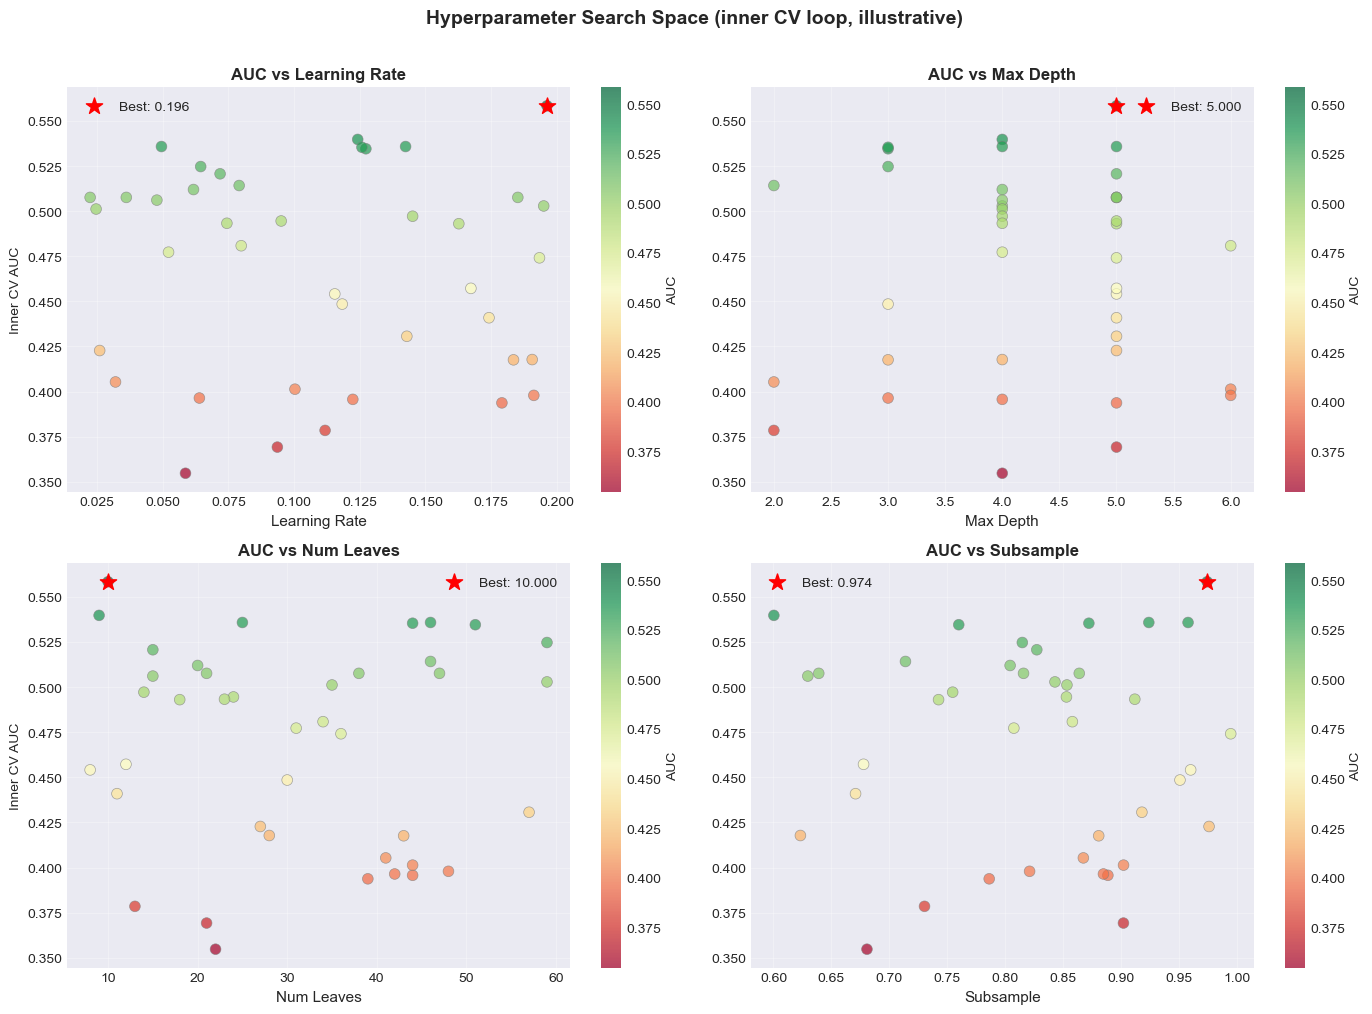

In [5]:
# Build a DataFrame of all combinations tried in the LAST outer fold's inner search
# (for illustration — full nested results are in outer_aucs)
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import lightgbm as lgb

inner_tscv_vis = TimeSeriesSplit(n_splits=3)
lgbm_vis       = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)

search_vis = RandomizedSearchCV(
    estimator=lgbm_vis, param_distributions=param_dist,
    n_iter=40, cv=inner_tscv_vis, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=0, return_train_score=True
)
search_vis.fit(X, y)

cv_results = pd.DataFrame(search_vis.cv_results_)

params_to_plot = [
    ('param_learning_rate', 'Learning Rate'),
    ('param_max_depth',     'Max Depth'),
    ('param_num_leaves',    'Num Leaves'),
    ('param_subsample',     'Subsample'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (param, label) in enumerate(params_to_plot):
    ax     = axes[i]
    x_vals = cv_results[param].astype(float)
    y_vals = cv_results['mean_test_score']

    sc = ax.scatter(x_vals, y_vals, c=y_vals, cmap='RdYlGn',
                    alpha=0.7, s=60, edgecolors='gray', linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='AUC')

    best_x = float(cv_results.loc[search_vis.best_index_, param])
    best_y = search_vis.best_score_
    ax.scatter([best_x], [best_y], color='red', s=150, zorder=5,
               marker='*', label=f'Best: {best_x:.3f}')

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Inner CV AUC' if i % 2 == 0 else '')
    ax.set_title(f'AUC vs {label}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Search Space (inner CV loop, illustrative)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 📈 Learning Curves with Early Stopping

In [6]:
# Build train/val split on first 80% of data (respects temporal order)
# This is illustrative — NOT used to select hyperparameters (no leakage here)
split_idx = int(len(X) * 0.8)
X_tr, X_val = X[:split_idx], X[split_idx:]
y_tr, y_val = y[:split_idx], y[split_idx:]

# Use the most common best params from nested CV folds
from collections import Counter

def most_common_params(params_list):
    """Return the param dict chosen most often across nested CV folds."""
    # Convert each dict to a frozenset for counting
    counted = Counter(frozenset(p.items()) for p in params_list)
    most_common_frozen = counted.most_common(1)[0][0]
    return dict(most_common_frozen)

best_params_display = most_common_params(best_params_list)
lc_params = {**best_params_display, 'random_state': 42, 'verbose': -1, 'n_jobs': -1,
             'n_estimators': 1000}

model_lc     = lgb.LGBMClassifier(**lc_params)
evals_result = {}

model_lc.fit(
    X_tr, y_tr,
    eval_set   = [(X_tr, y_tr), (X_val, y_val)],
    eval_names = ['train', 'valid'],
    eval_metric= 'auc',
    callbacks  = [
        lgb.early_stopping(50, verbose=False),
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(period=-1)
    ]
)

n_iters   = len(evals_result['train']['auc'])
best_iter = int(np.argmax(evals_result['valid']['auc'])) + 1
best_auc  = max(evals_result['valid']['auc'])

print(f'✅ Training stopped at iteration {n_iters}')
print(f'   Best iteration      : {best_iter}')
print(f'   Train AUC (final)   : {evals_result["train"]["auc"][-1]:.4f}')
print(f'   Validation AUC (best): {best_auc:.4f}')
print(f'   Train-val gap       : {evals_result["train"]["auc"][-1] - best_auc:.4f}')
print(f'   (gap > 0.10 suggests overfitting; early stopping mitigates this)')


✅ Training stopped at iteration 71
   Best iteration      : 21
   Train AUC (final)   : 0.9097
   Validation AUC (best): 0.5510
   Train-val gap       : 0.3587
   (gap > 0.10 suggests overfitting; early stopping mitigates this)


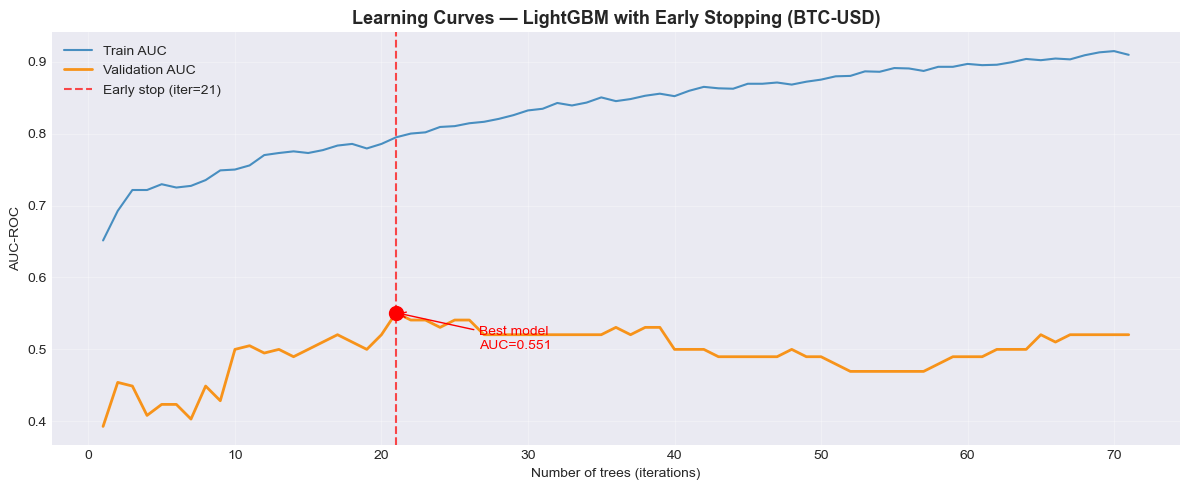

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

iters = range(1, n_iters + 1)
ax.plot(iters, evals_result['train']['auc'],
        label='Train AUC', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(iters, evals_result['valid']['auc'],
        label='Validation AUC', color='#f7931a', linewidth=2)
ax.axvline(best_iter, color='red', linestyle='--', alpha=0.7,
           label=f'Early stop (iter={best_iter})')
ax.scatter([best_iter], [best_auc], color='red', s=100, zorder=5)
ax.annotate(f'Best model\nAUC={best_auc:.3f}',
            xy=(best_iter, best_auc),
            xytext=(best_iter + max(5, n_iters*0.08), best_auc - 0.05),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_title('Learning Curves — LightGBM with Early Stopping (BTC-USD)', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of trees (iterations)')
ax.set_ylabel('AUC-ROC')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. 🏁 Final Optimised Model

In [8]:
# ── Final model: trained on the first 80% of data ─────────────────────────
# We use the most frequently selected hyperparameters from nested CV.
# Training on 80% ensures the last 20% is a true held-out test for NB4.
print('🔧 Most common best params from nested CV folds:')
for k, v in best_params_display.items():
    print(f'   {k:25s}: {v}')

final_params = {**best_params_display, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}

split_idx_final = int(len(X) * 0.80)
lgbm_final      = lgb.LGBMClassifier(**final_params)
lgbm_final.fit(X[:split_idx_final], y[:split_idx_final])

# ── Report honest (nested CV) performance ──────────────────────────────────
from sklearn.metrics import roc_auc_score as ras
overall_nested_auc = ras(nested_y_true, nested_y_prob)

print(f'\n🏆 Performance Summary')
print(f'   Baseline LightGBM AUC (walk-fwd) : {auc_baseline:.4f} ± {std_baseline:.4f}')
print(f'   Optimised AUC — INNER CV         : {search_vis.best_score_:.4f}  ← optimistic (DO NOT USE)')
print(f'   Optimised AUC — OUTER (Nested CV): {np.mean(outer_aucs):.4f} ± {np.std(outer_aucs):.4f}  ← honest')
print(f'   Overall OOS AUC (all outer folds): {overall_nested_auc:.4f}')
print(f'\n   Improvement over baseline        : {(overall_nested_auc - auc_baseline)*100:+.2f} pp (honest estimate)')
print(f'\n⚠️  The inner CV AUC ({search_vis.best_score_:.4f}) is inflated by hyperparameter selection.')
print(f'   The nested CV outer AUC ({np.mean(outer_aucs):.4f}) is the correct number to report.')

# Save model and params
joblib.dump(lgbm_final, MODELS_DIR / 'lgbm_optimized.joblib')
pd.Series(final_params).to_csv(DATA_DIR / 'best_params.csv', header=['value'])

print(f'\n💾 Model saved  : models/lgbm_optimized.joblib')
print(f'   (trained on first 80% only — last 20% reserved for backtesting in NB4)')


🔧 Most common best params from nested CV folds:
   max_depth                : 4
   reg_alpha                : 0.4055181959984358
   n_estimators             : 407
   num_leaves               : 25
   learning_rate            : 0.12572264246310147
   min_child_samples        : 21
   colsample_bytree         : 0.6460218265559116
   reg_lambda               : 0.07474135358698819
   subsample                : 0.6180211440955466

🏆 Performance Summary
   Baseline LightGBM AUC (walk-fwd) : 0.4826 ± 0.0308
   Optimised AUC — INNER CV         : 0.5584  ← optimistic (DO NOT USE)
   Optimised AUC — OUTER (Nested CV): 0.4982 ± 0.0500  ← honest
   Overall OOS AUC (all outer folds): 0.4606

   Improvement over baseline        : -2.21 pp (honest estimate)

⚠️  The inner CV AUC (0.5584) is inflated by hyperparameter selection.
   The nested CV outer AUC (0.4982) is the correct number to report.

💾 Model saved  : models/lgbm_optimized.joblib
   (trained on first 80% only — last 20% reserved for backtes

---
## ✅ Notebook 3 Summary

- ✔️ **Nested CV implemented** — inner loop tunes, outer loop evaluates honestly
- ✔️ **Inflated inner CV AUC clearly separated from honest outer AUC**
- ✔️ **Early stopping** prevents overfitting on small dataset
- ✔️ Final model trained on 80% only — last 20% untouched for NB4 backtesting
